In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import scipy.sparse as sp
import joblib
import os

print(" Libraries imported!")

 Libraries imported!


In [2]:
df_train = pd.read_csv("../data/resume_jd_train_cleaned.csv")
df_test = pd.read_csv("../data/resume_jd_test_cleaned.csv")

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)
print("\nColumns:", df_train.columns.tolist()) 

Train shape: (6240, 7)
Test shape: (1759, 7)

Columns: ['resume_text', 'job_description_text', 'label', 'resume_clean', 'jd_clean', 'cosine_similarity', 'bert_similarity']


In [3]:
print("Fitting TF-IDF vectorizer...")

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),    # unigrams + bigrams
    min_df=2,              # ignore very rare words
    max_df=0.95            # ignore very common words
)

# Fit ONLY on train data
# Transform both train and test
all_train_text = pd.concat([df_train['resume_clean'], 
                             df_train['jd_clean']])
tfidf.fit(all_train_text)

# Transform resumes and JDs separately
train_resume_tfidf = tfidf.transform(df_train['resume_clean'])
train_jd_tfidf     = tfidf.transform(df_train['jd_clean'])

test_resume_tfidf  = tfidf.transform(df_test['resume_clean'])
test_jd_tfidf      = tfidf.transform(df_test['jd_clean'])

print("TF-IDF done!")
print("Train resume matrix shape:", train_resume_tfidf.shape)

Fitting TF-IDF vectorizer...
TF-IDF done!
Train resume matrix shape: (6240, 5000)


In [4]:
print("Computing cosine similarity...")

# Similarity between each resume and its JD
train_similarity = [
    cosine_similarity(train_resume_tfidf[i], 
                      train_jd_tfidf[i])[0][0]
    for i in range(train_resume_tfidf.shape[0])
]

test_similarity = [
    cosine_similarity(test_resume_tfidf[i], 
                      test_jd_tfidf[i])[0][0]
    for i in range(test_resume_tfidf.shape[0])
]

df_train['cosine_similarity'] = train_similarity
df_test['cosine_similarity']  = test_similarity

print(" Cosine similarity computed!")
print("\nSample similarity scores:")
print(df_train['cosine_similarity'].describe())

Computing cosine similarity...
 Cosine similarity computed!

Sample similarity scores:
count    6240.000000
mean        0.089068
std         0.058890
min         0.000000
25%         0.047187
50%         0.075019
75%         0.114656
max         0.479855
Name: cosine_similarity, dtype: float64


In [5]:
print("Building feature matrix...")

# Convert similarity to sparse matrix
train_sim_sparse = sp.csr_matrix(
    np.array(train_similarity).reshape(-1, 1)
)
test_sim_sparse = sp.csr_matrix(
    np.array(test_similarity).reshape(-1, 1)
)

# Combine: TF-IDF features + cosine similarity
X_train = sp.hstack([train_resume_tfidf, 
                     train_jd_tfidf, 
                     train_sim_sparse])
X_test  = sp.hstack([test_resume_tfidf, 
                     test_jd_tfidf, 
                     test_sim_sparse])

print("✅ Feature matrix built!")
print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)

Building feature matrix...
✅ Feature matrix built!
X_train shape: (6240, 10001)
X_test shape:  (1759, 10001)


In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(df_train['label'])
y_test  = le.transform(df_test['label'])

print("✅ Labels encoded!")
print("Classes:", le.classes_)
print("Encoded as:", list(range(len(le.classes_))))

✅ Labels encoded!
Classes: ['Good Fit' 'No Fit' 'Potential Fit']
Encoded as: [0, 1, 2]


In [7]:
os.makedirs("../models", exist_ok=True)

# Save feature matrices
sp.save_npz("../data/X_train.npz", X_train)
sp.save_npz("../data/X_test.npz", X_test)

# Save labels
np.save("../data/y_train.npy", y_train)
np.save("../data/y_test.npy", y_test)

# Save vectorizer and encoder (needed later!)
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")
joblib.dump(le,   "../models/label_encoder.pkl")

# Save updated CSVs with cosine similarity
df_train.to_csv("../data/resume_jd_train_cleaned.csv", index=False)
df_test.to_csv("../data/resume_jd_test_cleaned.csv",  index=False)

print("Everything saved!")
print("\nSaved files:")
print("  data/X_train.npz")
print("  data/X_test.npz")
print("  data/y_train.npy")
print("  data/y_test.npy")
print("  models/tfidf_vectorizer.pkl")
print("  models/label_encoder.pkl")

Everything saved!

Saved files:
  data/X_train.npz
  data/X_test.npz
  data/y_train.npy
  data/y_test.npy
  models/tfidf_vectorizer.pkl
  models/label_encoder.pkl


In [8]:
import pandas as pd

df = pd.read_csv("../data/resume_jd_train_cleaned.csv")
print("Columns:", df.columns.tolist())
print("Shape:", df.shape)

Columns: ['resume_text', 'job_description_text', 'label', 'resume_clean', 'jd_clean', 'cosine_similarity', 'bert_similarity']
Shape: (6240, 7)


In [9]:
import scipy.sparse as sp
import numpy as np
import joblib

# Load everything back
X_train = sp.load_npz("../data/X_train.npz")
X_test  = sp.load_npz("../data/X_test.npz")
y_train = np.load("../data/y_train.npy")
y_test  = np.load("../data/y_test.npy")
le      = joblib.load("../models/label_encoder.pkl")

print("=== FEATURE MATRIX ===")
print(f"X_train shape:     {X_train.shape}")
print(f"X_test shape:      {X_test.shape}")

print("\n=== LABELS ===")
print(f"Classes:           {le.classes_}")
print(f"y_train samples:   {len(y_train)}")
print(f"y_test samples:    {len(y_test)}")

print("\n=== LABEL DISTRIBUTION (train) ===")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"{le.classes_[u]:15} → {c} samples")

print("\n=== COSINE SIMILARITY STATS ===")
df_train = pd.read_csv("../data/resume_jd_train_cleaned.csv")
print(df_train['cosine_similarity'].describe())

print("\n=== SAMPLE SCORES BY LABEL ===")
for label in le.classes_:
    avg = df_train[df_train['label']==label]['cosine_similarity'].mean()
    print(f"{label:15} → avg similarity: {avg:.4f}")

=== FEATURE MATRIX ===
X_train shape:     (6240, 10001)
X_test shape:      (1759, 10001)

=== LABELS ===
Classes:           ['Good Fit' 'No Fit' 'Potential Fit']
y_train samples:   6240
y_test samples:    1759

=== LABEL DISTRIBUTION (train) ===
Good Fit        → 1542 samples
No Fit          → 3142 samples
Potential Fit   → 1556 samples

=== COSINE SIMILARITY STATS ===
count    6240.000000
mean        0.089068
std         0.058890
min         0.000000
25%         0.047187
50%         0.075019
75%         0.114656
max         0.479855
Name: cosine_similarity, dtype: float64

=== SAMPLE SCORES BY LABEL ===
Good Fit        → avg similarity: 0.1082
No Fit          → avg similarity: 0.0746
Potential Fit   → avg similarity: 0.0994


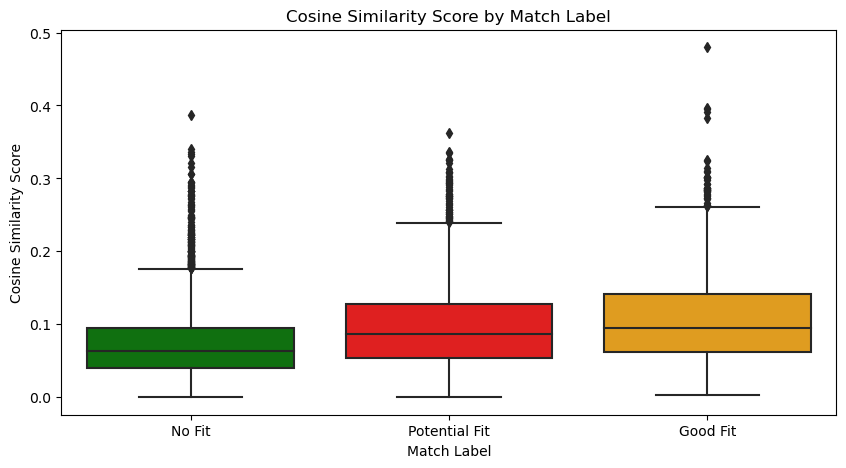

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_train, 
            x='label', 
            y='cosine_similarity',
            palette=['green', 'red', 'orange'])
plt.title('Cosine Similarity Score by Match Label')
plt.xlabel('Match Label')
plt.ylabel('Cosine Similarity Score')
plt.savefig('../data/similarity_by_label.png')
plt.show()

The above graph shows that : 

Good Fit has the highest cosine similarity ,then Potential Fit then No Fit .
 Our similarity SCORES align with the existing labels

In [11]:
import joblib
import numpy as np
import scipy.sparse as sp

# Load everything
tfidf = joblib.load("../models/tfidf_vectorizer.pkl")
X_train = sp.load_npz("../data/X_train.npz")

# Get feature names (only 5000)
feature_names = tfidf.get_feature_names_out()
print(f"Total TF-IDF features: {len(feature_names)}")

# Get a Good Fit resume
good_fit_idx = df_train[df_train['label']=='Good Fit'].index[0]

# Extract ONLY the first 5000 columns (resume TF-IDF part)
resume_vector = X_train[good_fit_idx, :5000].toarray()[0]

# Get top 20 keywords
top_indices = resume_vector.argsort()[-20:][::-1]

print("\n=== TOP 20 KEYWORDS FROM A GOOD FIT RESUME ===")
for i in top_indices:
    print(f"{feature_names[i]:30} → {resume_vector[i]:.4f}")

# Also show top keywords from its JD
jd_vector = X_train[good_fit_idx, 5000:10000].toarray()[0]
top_jd_indices = jd_vector.argsort()[-20:][::-1]

print("\n=== TOP 20 KEYWORDS FROM MATCHING JD ===")
for i in top_jd_indices:
    print(f"{feature_names[i]:30} → {jd_vector[i]:.4f}")

# Show which keywords appear in BOTH
resume_top = set([feature_names[i] for i in top_indices])
jd_top = set([feature_names[i] for i in top_jd_indices])
common = resume_top & jd_top

print("\n=== KEYWORDS MATCHING IN BOTH ===")
print(common if common else "No exact matches found")

Total TF-IDF features: 5000

=== TOP 20 KEYWORDS FROM A GOOD FIT RESUME ===
hibernate                      → 0.3432
good knowledge                 → 0.2061
test                           → 0.1855
application                    → 0.1800
developed                      → 0.1798
good                           → 0.1726
oriented                       → 0.1450
mapping                        → 0.1314
testing                        → 0.1202
object                         → 0.1146
agile scrum                    → 0.1087
spring                         → 0.0961
architecture                   → 0.0943
test case                      → 0.0942
oop                            → 0.0932
knowledge                      → 0.0912
spring framework               → 0.0904
using                          → 0.0889
used                           → 0.0885
scrum                          → 0.0880

=== TOP 20 KEYWORDS FROM MATCHING JD ===
senior software                → 0.3214
software engineer              → 0.2180
da

In the above output , we can see the top 20 keywords from a good fit labelled resume .
But still even for a good fit labelled resume the cosine similarity score is low. This shows that tf-idf only performs keyword matching .. It cant recognise that a candidate with skills of Java devloper is close to skills of a software engineer . So we need to perform semantic matching next .

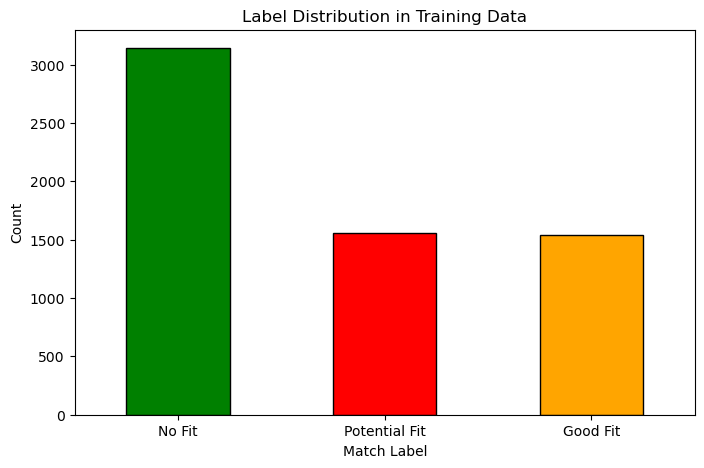

In [12]:
plt.figure(figsize=(8, 5))
df_train['label'].value_counts().plot(
    kind='bar',
    color=['green', 'red', 'orange'],
    edgecolor='black'
)
plt.title('Label Distribution in Training Data')
plt.xlabel('Match Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.savefig('../data/label_distribution.png')
plt.show()

The graph shows that the dataset contains 
more 'No Fit' pairs, reflecting real world 
recruitment where most resumes submitted 
do not match the job requirements, and 
only a fraction are considered Good Fit.